# RazorShield AI — exploratory data analysis

What the synthetic transaction data actually looks like, before any model is
fitted. The point of this pass is to decide **which features carry signal, how
imbalanced the problem is, and where a model is likely to struggle** — not to
produce pretty charts.

Everything below reads `data/raw/transactions.csv`, the released dataset. The
ground-truth sidecar (`transactions_meta.csv`) is used only to break results
down by fraud pattern; it is never a model input.

Regenerate the data first if it is missing:

```
python -m razorshield.data.generate --out data/raw
```

In [1]:
import json
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW = ROOT / "data" / "raw"

df = pd.read_csv(RAW / "transactions.csv", parse_dates=["timestamp"])
meta = pd.read_csv(RAW / "transactions_meta.csv")
manifest = json.loads((RAW / "manifest.json").read_text())

# Chart tokens. One sequential hue for magnitude, a diverging pair for signed
# values, and the reserved status ladder for risk bands -- colour never carries
# meaning on its own, so every chart is also directly labelled.
INK, INK_2, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, SURFACE = "#e1e0d9", "#fcfcfb"
BLUE, RED = "#2a78d6", "#e34948"
BANDS = {"LOW": "#0ca30c", "MEDIUM": "#fab219", "HIGH": "#ec835a", "CRITICAL": "#d03b3b"}

mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.labelcolor": INK_2, "axes.titlecolor": INK,
    "axes.titlesize": 11, "axes.titleweight": "600", "axes.labelsize": 9,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "xtick.labelsize": 8.5, "ytick.labelsize": 8.5,
    "font.family": "sans-serif", "font.size": 9,
    "figure.dpi": 120, "legend.frameon": False, "legend.fontsize": 8.5,
})

print(f"rows      {len(df):,}")
print(f"columns   {len(df.columns)}")
print(f"window    {df.timestamp.min():%Y-%m-%d} to {df.timestamp.max():%Y-%m-%d}")
print(f"customers {df.customer_id.nunique():,}   merchants {df.merchant_id.nunique():,}")

rows      100,000
columns   23
window    2025-03-02 to 2025-06-24
customers 9,729   merchants 300


## 1. Balance, completeness, and what a naive baseline scores

The first number that matters is the base rate. At ~3% positives, accuracy is a
useless metric: predicting "never fraud" scores 97% and catches nothing. That is
the whole reason the model comparison reports PR-AUC.

In [2]:
fraud_rate = df.is_fraud.mean()
n_fraud = int(df.is_fraud.sum())

print(f"fraud            {n_fraud:,} of {len(df):,}  ({fraud_rate:.2%})")
print(f"legitimate       {len(df) - n_fraud:,}  ({1 - fraud_rate:.2%})")
print(f"imbalance ratio  1 : {(len(df) - n_fraud) / n_fraud:.0f}")
print()
print(f"accuracy of 'always legitimate' : {1 - fraud_rate:.2%}  <- catches zero fraud")
print()

nulls = df.isna().sum()
print(f"missing values   {int(nulls.sum())} across all {len(df.columns)} columns")
print(f"duplicate ids    {int(df.transaction_id.duplicated().sum())}")
print()

# Fraud rows by generating pattern. hard_negative rows are labelled 0 -- they
# are genuine customers who look like fraud, and they set the precision ceiling.
patterns = meta.fraud_archetype.value_counts()
print("rows by generating pattern")
for name, n in patterns.items():
    tag = "  (labelled legitimate)" if name == "hard_negative" else ""
    label = "none (ordinary traffic)" if name == "none" else name
    print(f"  {label:<26} {n:>7,}{tag}")
print()
print(f"label noise      {int(meta.label_flipped.sum())} rows where the shipped label "
      f"disagrees with ground truth")

fraud            3,082 of 100,000  (3.08%)
legitimate       96,918  (96.92%)
imbalance ratio  1 : 31

accuracy of 'always legitimate' : 96.92%  <- catches zero fraud

missing values   0 across all 23 columns
duplicate ids    0

rows by generating pattern
  none (ordinary traffic)     96,430
  ato_burst                    1,035
  slow_bleed                     647
  card_testing                   618
  hard_negative                  489  (labelled legitimate)
  device_swap_drain              474
  merchant_collusion             307

label noise      109 rows where the shipped label disagrees with ground truth


## 2. Amounts

Transaction amounts are lognormal and span four orders of magnitude, so they are
plotted on a log axis — a linear histogram would be one spike at zero.

Two things to look for: fraud sits higher in absolute terms, but the *ratio* to
the customer's own average is the sharper signal. A ₹9,000 purchase is
unremarkable for someone who usually spends ₹8,000.

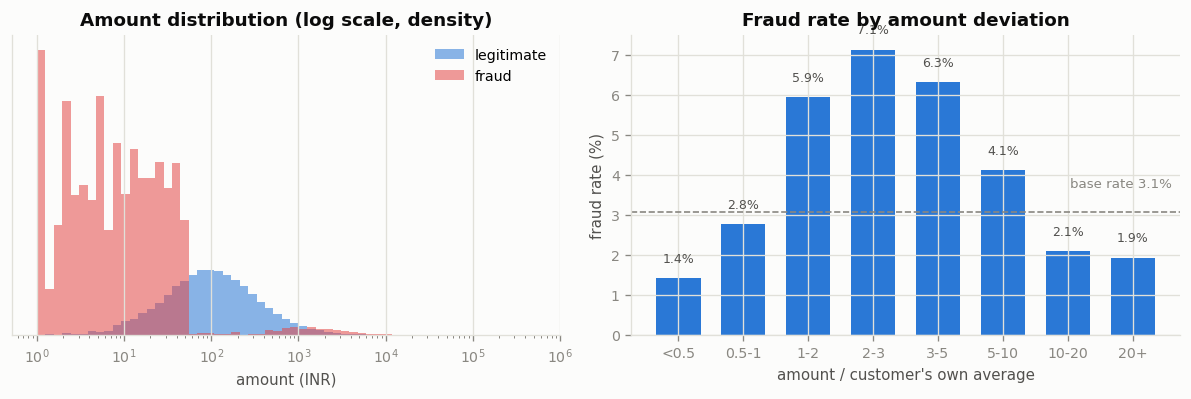

median amount   legitimate Rs511   fraud Rs2,373
median deviation  legitimate 0.50x   fraud 1.28x


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))

legit = df.loc[df.is_fraud == 0, "amount"]
fraud = df.loc[df.is_fraud == 1, "amount"]
bins = np.logspace(0, np.log10(max(df.amount.max(), 10)), 60)

ax = axes[0]
ax.hist(legit, bins=bins, color=BLUE, alpha=0.55, label="legitimate", density=True)
ax.hist(fraud, bins=bins, color=RED, alpha=0.55, label="fraud", density=True)
ax.set_xscale("log")
ax.set_title("Amount distribution (log scale, density)")
ax.set_xlabel("amount (INR)")
ax.set_yticks([])
ax.legend(loc="upper right")

ax = axes[1]
dev_bins = [0, 0.5, 1, 2, 3, 5, 10, 20, 100]
labels = ["<0.5", "0.5-1", "1-2", "2-3", "3-5", "5-10", "10-20", "20+"]
grp = df.groupby(pd.cut(df.amount_deviation_ratio, dev_bins, labels=labels),
                 observed=True).is_fraud.agg(["mean", "size"])
ax.bar(range(len(grp)), grp["mean"] * 100, color=BLUE, width=0.68)
ax.axhline(fraud_rate * 100, color=MUTED, lw=1, ls="--")
ax.text(len(grp) - 0.4, fraud_rate * 100 + 0.6, f"base rate {fraud_rate:.1%}",
        ha="right", fontsize=8, color=MUTED)
for i, m in enumerate(grp["mean"]):
    ax.text(i, m * 100 + 0.4, f"{m:.1%}", ha="center", fontsize=7.5, color=INK_2)
ax.set_xticks(range(len(grp)))
ax.set_xticklabels(grp.index, rotation=0)
ax.set_title("Fraud rate by amount deviation")
ax.set_xlabel("amount / customer's own average")
ax.set_ylabel("fraud rate (%)")

plt.tight_layout()
plt.show()

print(f"median amount   legitimate Rs{legit.median():,.0f}   fraud Rs{fraud.median():,.0f}")
print(f"median deviation  legitimate {df.loc[df.is_fraud==0,'amount_deviation_ratio'].median():.2f}x"
      f"   fraud {df.loc[df.is_fraud==1,'amount_deviation_ratio'].median():.2f}x")

## 3. When, how, and on what device

Fraud **rate** rather than fraud **count** — counts just track traffic volume, so
a bar chart of them says only "UPI is popular". Group sizes are printed so a high
rate on a thin slice is visible as such.

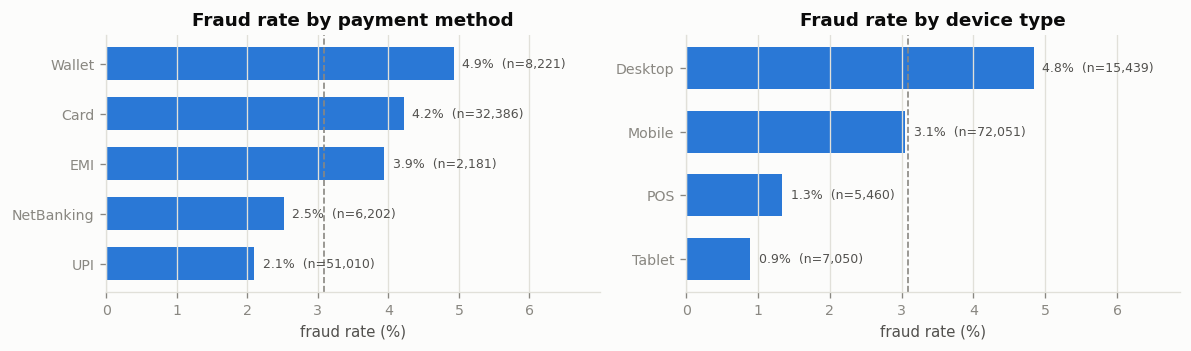

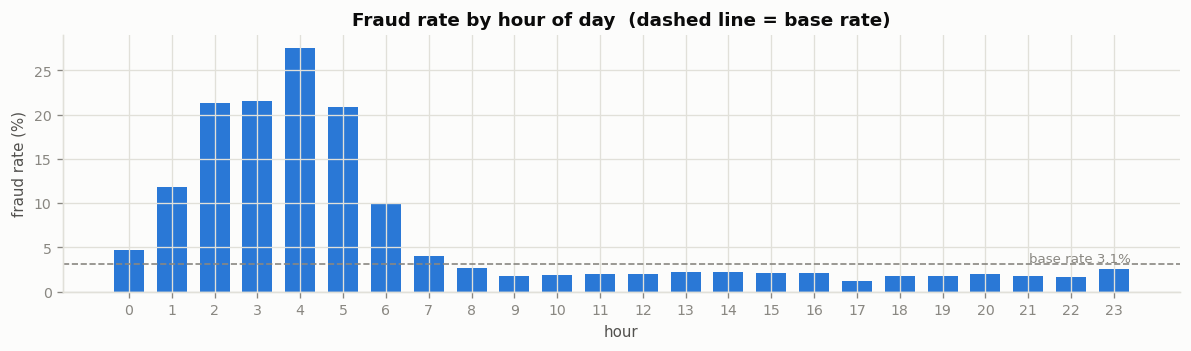

00:00-05:59  7,495 transactions, fraud 14.57%  (4.7x the base rate)


In [4]:
def rate_by(column, ax, title, order=None):
    grp = df.groupby(column, observed=True).is_fraud.agg(["mean", "size"])
    if order is not None:
        grp = grp.reindex(order).dropna()
    grp = grp.sort_values("mean", ascending=False)
    ax.barh(range(len(grp)), grp["mean"] * 100, color=BLUE, height=0.66)
    ax.axvline(fraud_rate * 100, color=MUTED, lw=1, ls="--")
    ax.set_yticks(range(len(grp)))
    ax.set_yticklabels(grp.index)
    ax.invert_yaxis()
    for i, (m, n) in enumerate(zip(grp["mean"], grp["size"], strict=True)):
        ax.text(m * 100 + 0.12, i, f"{m:.1%}  (n={n:,})", va="center",
                fontsize=7.5, color=INK_2)
    ax.set_title(title)
    ax.set_xlabel("fraud rate (%)")
    ax.set_xlim(0, max(grp["mean"]) * 100 * 1.42)
    ax.grid(axis="y", visible=False)
    return grp

fig, axes = plt.subplots(1, 2, figsize=(10, 3.0))
rate_by("payment_method", axes[0], "Fraud rate by payment method")
rate_by("device_type", axes[1], "Fraud rate by device type")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 3.0))
hourly = df.groupby("transaction_hour").is_fraud.agg(["mean", "size"])
ax.bar(hourly.index, hourly["mean"] * 100, color=BLUE, width=0.7)
ax.axhline(fraud_rate * 100, color=MUTED, lw=1, ls="--")
ax.text(23.4, fraud_rate * 100 + 0.25, f"base rate {fraud_rate:.1%}",
        ha="right", fontsize=8, color=MUTED)
ax.set_xticks(range(0, 24))
ax.set_title("Fraud rate by hour of day  (dashed line = base rate)")
ax.set_xlabel("hour")
ax.set_ylabel("fraud rate (%)")
ax2 = ax.twiny()   # volume as context only, on its own independent axis
ax2.set_xticks([])
plt.tight_layout()
plt.show()

night = df[df.transaction_hour.between(0, 5)]
print(f"00:00-05:59  {len(night):,} transactions, fraud {night.is_fraud.mean():.2%}"
      f"  ({night.is_fraud.mean() / fraud_rate:.1f}x the base rate)")

## 4. Velocity, device age and history

These are the behavioural features — the ones a payment gateway cannot send us
and that RazorShield has to maintain itself. If they carry signal, the event
store earns its place.

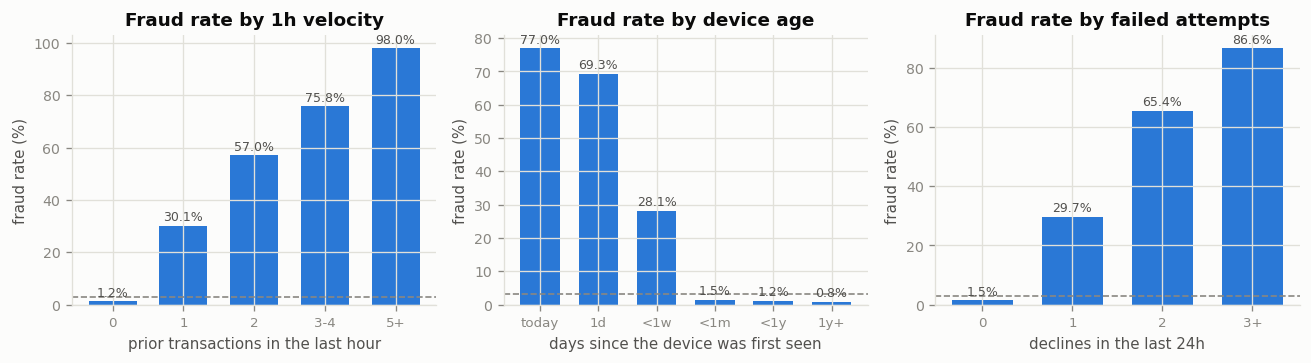

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.1))

def bucket_rate(series, bins, labels, ax, title, xlabel):
    grp = df.groupby(pd.cut(series, bins, labels=labels, include_lowest=True),
                     observed=True).is_fraud.agg(["mean", "size"])
    ax.bar(range(len(grp)), grp["mean"] * 100, color=BLUE, width=0.68)
    ax.axhline(fraud_rate * 100, color=MUTED, lw=1, ls="--")
    for i, m in enumerate(grp["mean"]):
        ax.text(i, m * 100 + max(grp["mean"]) * 100 * 0.02, f"{m:.1%}",
                ha="center", fontsize=7.5, color=INK_2)
    ax.set_xticks(range(len(grp)))
    ax.set_xticklabels(grp.index, fontsize=8)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("fraud rate (%)")
    return grp

bucket_rate(df.transactions_last_1h, [-0.1, 0, 1, 2, 4, 100],
            ["0", "1", "2", "3-4", "5+"], axes[0],
            "Fraud rate by 1h velocity", "prior transactions in the last hour")
bucket_rate(df.device_age_days, [-0.1, 0, 1, 7, 30, 365, 100000],
            ["today", "1d", "<1w", "<1m", "<1y", "1y+"], axes[1],
            "Fraud rate by device age", "days since the device was first seen")
bucket_rate(df.failed_attempts_24h, [-0.1, 0, 1, 2, 100],
            ["0", "1", "2", "3+"], axes[2],
            "Fraud rate by failed attempts", "declines in the last 24h")

plt.tight_layout()
plt.show()

## 5. How separable is each feature on its own?

Single-feature ROC-AUC, folded so 0.5 means "no signal" regardless of direction.
Anything approaching 1.0 would mean the generator leaked the label into a
feature; the quality gate in `validate.py` fails the build above 0.95.

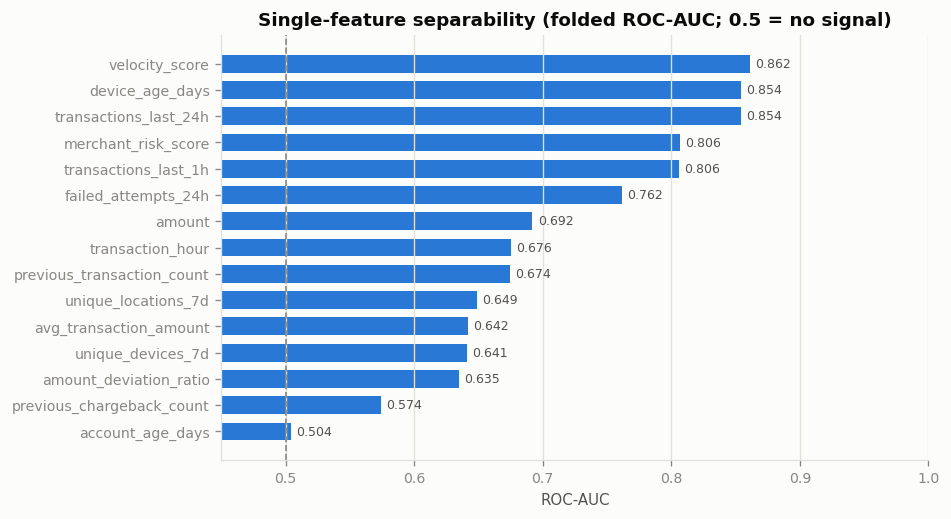

strongest single feature : velocity_score at 0.862
no feature approaches 1.0, so nothing here is a relabelled target.


In [6]:
from sklearn.metrics import roc_auc_score

numeric = df.select_dtypes("number").columns.drop("is_fraud")
auc = {}
for col in numeric:
    a = roc_auc_score(df.is_fraud, df[col])
    auc[col] = max(a, 1 - a)
auc = pd.Series(auc).sort_values()

fig, ax = plt.subplots(figsize=(8, 4.4))
ax.barh(range(len(auc)), auc.values, color=BLUE, height=0.68)
ax.axvline(0.5, color=MUTED, lw=1, ls="--")
ax.set_yticks(range(len(auc)))
ax.set_yticklabels(auc.index)
for i, v in enumerate(auc.values):
    ax.text(v + 0.004, i, f"{v:.3f}", va="center", fontsize=7.5, color=INK_2)
ax.set_xlim(0.45, 1.0)
ax.set_title("Single-feature separability (folded ROC-AUC; 0.5 = no signal)")
ax.set_xlabel("ROC-AUC")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

print(f"strongest single feature : {auc.index[-1]} at {auc.iloc[-1]:.3f}")
print("no feature approaches 1.0, so nothing here is a relabelled target.")

## 6. Correlations

Correlation is a signed quantity, so it gets a diverging scale with a neutral
midpoint — a single-hue ramp would make "strongly negative" and "zero" look
alike. Watch for feature pairs that are near-duplicates: they inflate a linear
model's variance without adding information.

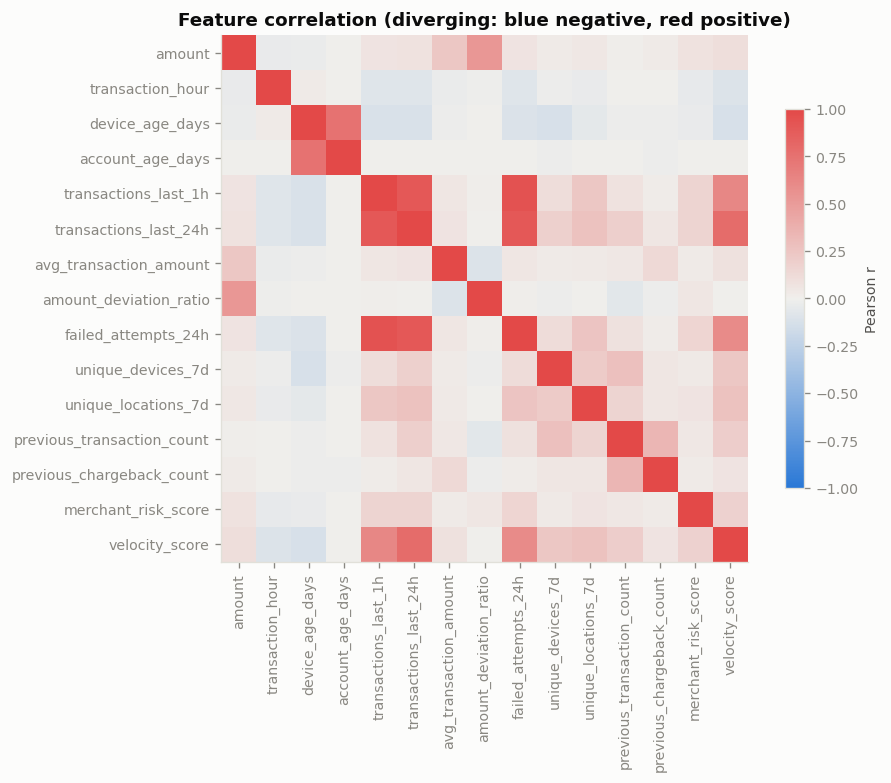

most correlated pairs
  transactions_last_1h         failed_attempts_24h          +0.945
  transactions_last_1h         transactions_last_24h        +0.906
  transactions_last_24h        failed_attempts_24h          +0.900
  transactions_last_24h        velocity_score               +0.783
  device_age_days              account_age_days             +0.743
  transactions_last_1h         velocity_score               +0.623


In [7]:
corr = df[numeric].corr()

fig, ax = plt.subplots(figsize=(8.2, 6.6))
im = ax.imshow(corr, cmap=mpl.colors.LinearSegmentedColormap.from_list(
    "div", [BLUE, "#f0efec", RED]), vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticks(range(len(corr)))
ax.set_yticklabels(corr.columns)
ax.grid(visible=False)
cb = fig.colorbar(im, ax=ax, shrink=0.72)
cb.set_label("Pearson r", fontsize=8.5, color=INK_2)
ax.set_title("Feature correlation (diverging: blue negative, red positive)")
plt.tight_layout()
plt.show()

pairs = (corr.where(np.triu(np.ones(corr.shape), 1).astype(bool))
             .stack().sort_values(key=abs, ascending=False).head(6))
print("most correlated pairs")
for (a, b), v in pairs.items():
    print(f"  {a:<28} {b:<28} {v:+.3f}")

## 7. Where a model will struggle

Fraud is not one behaviour. Broken down by the pattern that generated it, the
signal ranges from blatant to invisible — and one group of rows is labelled
*legitimate* while looking exactly like an attack.

In [8]:
joined = df.join(meta.set_index("transaction_id"), on="transaction_id")
cols = ["amount_deviation_ratio", "device_age_days", "transactions_last_1h",
        "velocity_score", "merchant_risk_score"]

groups = ["none", "hard_negative", "slow_bleed", "merchant_collusion",
          "device_swap_drain", "ato_burst", "card_testing"]
table = (joined[joined.fraud_archetype.isin(groups)]
         .groupby("fraud_archetype")[cols].median().reindex(groups))
table.insert(0, "rows", joined.fraud_archetype.value_counts().reindex(groups))
table.index = ["ordinary traffic", "hard negative (label 0)", "slow_bleed",
               "merchant_collusion", "device_swap_drain", "ato_burst", "card_testing"]
display(table.round(3))

print()
print("Read the first two rows against each other: a hard negative is a genuine")
print("customer on a brand-new device making an unusually large purchase. It is")
print("built to be indistinguishable from ato_burst, and it is labelled 0.")
print()
print("slow_bleed sits almost on top of ordinary traffic on every column. That is")
print("the group the model misses, and no threshold fixes it.")

,rows,amount_deviation_ratio,device_age_days,transactions_last_1h,velocity_score,merchant_risk_score
ordinary traffic,96430,0.495,347.0,0.0,0.000,0.010
hard negative (label 0),489,1.885,0.0,2.0,0.660,0.029
slow_bleed,647,1.000,272.0,0.0,0.171,0.029
merchant_collusion,307,1.612,236.0,0.0,0.190,0.147
device_swap_drain,474,1.767,1.0,1.0,0.574,0.032
ato_burst,1035,2.292,1.0,4.0,0.740,0.033
card_testing,618,0.037,0.0,9.0,0.804,0.054



Read the first two rows against each other: a hard negative is a genuine
customer on a brand-new device making an unusually large purchase. It is
built to be indistinguishable from ato_burst, and it is labelled 0.

slow_bleed sits almost on top of ordinary traffic on every column. That is
the group the model misses, and no threshold fixes it.


## What this implies for modelling

1. **Report PR-AUC, not accuracy.** At a ~3% base rate, "always legitimate"
   scores ~97% accuracy and catches nothing.
2. **Split by time, never at random.** Behavioural features are built from each
   customer's own past; a random split lets a customer's later transactions
   inform predictions about their earlier ones.
3. **The behavioural features carry the signal.** Device age, velocity and amount
   deviation separate far better than anything on the payment itself — which is
   the argument for maintaining an event store rather than scoring the webhook
   payload alone.
4. **Precision has a hard ceiling.** The hard-negative rows are genuine customers
   that look identical to account takeover. No model separates them, so any
   claimed precision near 1.0 would mean a leak.
5. **Recall has a hard floor.** `slow_bleed` overlaps ordinary traffic on every
   feature here. Catching it needs sequence modelling, not a better classifier.

Next: `python -m razorshield.models.compare --data data/raw --out reports`.